# **Homework 2: Machine Learning for Regression**

The goal of this homework is to create a regression model for predicting the car fuel efficiency (column 'fuel_efficiency_mpg').

In [19]:
# %pip install pandas
# %pip install matplotlib
# %pip install seaborn
# %pip install numpy

In [20]:
# Import block

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [21]:
# Creating the dataframe

df = pd.read_csv('https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv', sep = ',')

df.columns = df.columns.str.lower().str.replace(' ', '_')

df.head() # Shows the first 5 rows of dataset

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [22]:
# Preparing the dataset
df.dtypes

model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors                int64
engine_displacement      int64
num_cylinders            int64
horsepower             float64
vehicle_weight           int64
acceleration           float64
fuel_efficiency_mpg    float64
dtype: object

In [23]:
dados = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']
df = df[dados]

var_qty = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
# var_cat = ['model_year']

### **EDA**

Look at the `fuel_efficiency_mpg variable`. Does it have a long tail?

**Answer:** *No, it shows a normal distribution.*

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

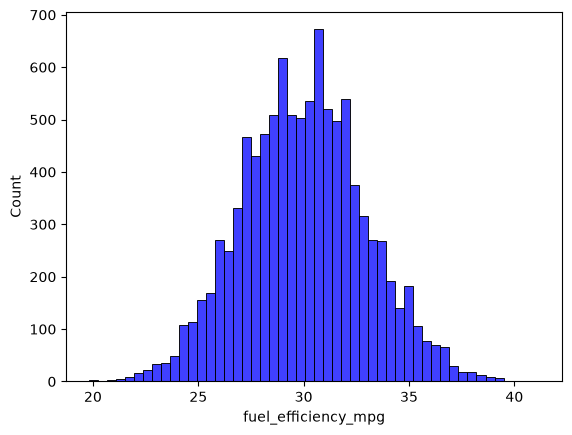

In [24]:
sns.histplot(df.fuel_efficiency_mpg, color = 'blue', bins = 50)

### **Question 1**
There's one column with missing values. What is it?

In [25]:
df.isna().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

### **Question 2**
What's the median (50% percentile) for variable `'horsepower'`?

In [26]:
md = df['horsepower'].median()
print(f'The media of the variable Horsepower is {md}.')

The media of the variable Horsepower is 254.0.


### ***Prepare and split the dataset***
Shuffle the filtered dataset and create the split exactly as in the lecture:

In [27]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

#Drop the index
df_train = df_train.reset_index(drop = True)
df_val = df_val.reset_index(drop = True)
df_test = df_test.reset_index(drop = True)

#Define target variables
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

#Drop the variable column
del df_test['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_train['fuel_efficiency_mpg']

#The returns are:
n, n_val, n_test, n_train, df_train.shape[0], df_val.shape[0], df_test.shape[0]

(10000, 2000, 2000, 6000, 6000, 2000, 2000)

### **Question 3**
- We need to deal with missing values for the column from Q1.
- We have two options: fill it with 0 or with the mean of this variable.
- Try both options. For each, train a linear regression model without regularization using the code from the lessons.
- For computing the mean, use the training only!
Use the validation dataset to evaluate the models and compare the RMSE of each option.
- Round the RMSE scores to 3 decimal digits using round(score, 3). This keeps the imputation difference visible in this release.

*Which option gives better RMSE?*

In [28]:
# Filling with 0
def prepare_X0(df):
    df_num = df.copy()
    df_num = df[var_qty].fillna(0)
    X = df_num.values
    return X

# Filling with Mean
def prepare_Xmean(df):
    df_num = df.copy()
    df_num = df[var_qty].fillna(df[var_qty].mean())
    X = df_num.values
    return X

#RMSE
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

# Linear Regression
def linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]

In [29]:
# Training the fill 0
X_train0 = prepare_X0(df_train)
w0, w1 = linear_regression(X_train0, y_train)
X_val0 = prepare_X0(df_val)
y_pred0 = w0 + X_val0.dot(w1)

# RMSE
rmse0 = rmse(y_val, y_pred0)

print(f'The RMSE filling with 0 is {round(rmse0, 3)}.')

The RMSE filling with 0 is 2.205.


In [30]:
# Training the fill mean
X_train_mean = prepare_Xmean(df_train)
w0, w1 = linear_regression(X_train_mean, y_train)
X_val_mean = prepare_Xmean(df_val)
y_pred_mean = w0 + X_val_mean.dot(w1)

# RMSE
rmse_mean = rmse(y_val, y_pred_mean)

print(f'The RMSE filling with the mean is {round(rmse_mean, 3)}.')

The RMSE filling with the mean is 2.202.


### **Question 4**
- Now let's train a regularized linear regression.
- For this question, fill the NAs with 0.
- Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
- Use RMSE to evaluate the model on the validation dataset.
- Round the RMSE scores to 4 decimal digits. This keeps the small but real regularization differences visible instead of turning several choices into a tie.

*Which `r` gives the best RMSE?*

In [31]:
# Linear Regression Regularization
def linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train0 = prepare_X0(df_train)
    w0, w1 = linear_regression_reg(X_train0, y_train, r=r)
    X_val0 = prepare_X0(df_val)
    y_pred0 = w0 + X_val0.dot(w1)
    rmse0 = rmse(y_val, y_pred0)
    print(f'The RMSE for r = {r} is {round(rmse0, 4)}.')

The RMSE for r = 0 is 2.2053.
The RMSE for r = 0.01 is 2.2058.
The RMSE for r = 0.1 is 2.2241.
The RMSE for r = 1 is 2.3492.
The RMSE for r = 5 is 2.4094.
The RMSE for r = 10 is 2.4195.
The RMSE for r = 100 is 2.4292.


###**Question 5**
- We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
- Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
- For each seed, do the train/validation/test split with 60%/20%/20% distribution.
- Fill the missing values with 0 and train a model without regularization.
- For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
- What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
- Round the result to 3 decimal digits (round(std, 3))

*What's the value of std?*

>Note: Standard deviation shows how different the values are. If it's low, then all values are approximately the same. If it's high, the values are different. If standard deviation of scores is low, then our model is stable.

In [32]:
scores = []
for i in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
  n = len(df)
  n_val = int(n * 0.2)
  n_test = int(n * 0.2)
  n_train = n - n_val - n_test

  np.random.seed(i)
  idx = np.arange(n)
  np.random.shuffle(idx)

  df_train = df.iloc[idx[:n_train]]
  df_val = df.iloc[idx[n_train:n_train + n_val]]
  df_test = df.iloc[idx[n_train + n_val:]]

  df_train = df_train.reset_index(drop = True)
  df_val = df_val.reset_index(drop = True)
  df_test = df_test.reset_index(drop = True)

  y_train = df_train.fuel_efficiency_mpg.values
  y_val = df_val.fuel_efficiency_mpg.values
  y_test = df_test.fuel_efficiency_mpg.values

  del df_test['fuel_efficiency_mpg']
  del df_val['fuel_efficiency_mpg']
  del df_train['fuel_efficiency_mpg']

  def prepare_X(df):
    df_num = df.copy()
    df_num = df[var_qty].fillna(0)
    X = df_num.values
    return X

  # Training
  X_train = prepare_X(df_train)
  w0, w1 = linear_regression(X_train, y_train)
  X_val = prepare_X(df_val)
  y_pred = w0 + X_val.dot(w1)

  # RMSE
  score = rmse(y_val, y_pred)
  scores.append(round(score, 3))

  print(f'For the seed {i} the final RMSE is {round(score, 3)}.')

std_dev = np.std(scores)
print(f'Standard deviation: {round(std_dev, 3)}')

For the seed 0 the final RMSE is 2.239.
For the seed 1 the final RMSE is 2.202.
For the seed 2 the final RMSE is 2.163.
For the seed 3 the final RMSE is 2.204.
For the seed 4 the final RMSE is 2.202.
For the seed 5 the final RMSE is 2.246.
For the seed 6 the final RMSE is 2.27.
For the seed 7 the final RMSE is 2.191.
For the seed 8 the final RMSE is 2.217.
For the seed 9 the final RMSE is 2.207.
Standard deviation: 0.029


###**Question 6**
- Split the dataset like previously, use seed 9.
- Combine train and validation datasets.
- Fill the missing values with 0 and train a model with r=0.001.

*What's the RMSE on the test dataset?*


In [33]:
for s in [8]:
  np.random.seed(i)
  idx = np.arange(n)
  np.random.shuffle(idx)

  df_train = df.iloc[idx[:n_train]]
  df_val = df.iloc[idx[n_train:n_train + n_val]]
  df_test = df.iloc[idx[n_train + n_val:]]

  df_train = df_train.reset_index(drop = True)
  df_val = df_val.reset_index(drop = True)
  df_test = df_test.reset_index(drop = True)

  y_train = df_train.fuel_efficiency_mpg.values
  y_val = df_val.fuel_efficiency_mpg.values
  y_test = df_test.fuel_efficiency_mpg.values

  del df_test['fuel_efficiency_mpg']
  del df_val['fuel_efficiency_mpg']
  del df_train['fuel_efficiency_mpg']

  def prepare_X(df):
    df_num = df.copy()
    df_num = df[var_qty].fillna(0)
    X = df_num.values
    return X

  # Training
  df_full_train = pd.concat([df_train, df_val])
  df_full_train = df_full_train.reset_index(drop=True)

  X_full_train = prepare_X(df_full_train)
  y_full_train = np.concatenate([y_train, y_val])

  w0, w1 = linear_regression_reg(X_full_train, y_full_train, r=0.001)
  x_test = prepare_X(df_test)
  y_pred = w0 + x_test.dot(w1)
  score1 = rmse(y_test, y_pred)

  print(f'For the seed {s} the final RMSE is {round(score1, 3)}.')

#   # RMSE
#   score = rmse(y_val, y_pred)
#   scores.append(round(score, 3))

#   print(f'For the seed {i} the final RMSE is {round(score, 3)}.')

# std_dev = np.std(scores)
# print(f'Standard deviation: {round(std_dev, 3)}')

For the seed 8 the final RMSE is 2.236.
